# XGBoost Grid Search

This notebook performs a basic experiment for hyperparameter tuning for XGBoost models using grid search.

In [ ]:
# Import libraries
import pandas as pd
from model import train_best_model

In [2]:

files = {'Dataset_1/2visit_CN_MCI.csv','Dataset_1/2visit_MCI_AD.csv', 'Dataset_1/3visit_CN_MCI.csv','Dataset_1/3visit_MCI_AD.csv', 'Dataset_1/4visit_CN_MCI.csv','Dataset_1/4visit_MCI_AD.csv'
         'Dataset_1/5visit_CN_MCI.csv','Dataset_1/5visit_MCI_AD.csv'}

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

In [ ]:
# Batch grid search across datasets and progression types, saving artifacts and reports
import os
from datetime import datetime
from model import train_best_model

# Datasets and their progression type
files = [
    ("Dataset_1/2visit_CN_MCI.csv", "MCI"),
    ("Dataset_1/2visit_MCI_AD.csv", "AD"),
    ("Dataset_1/3visit_CN_MCI.csv", "MCI"),
    ("Dataset_1/3visit_MCI_AD.csv", "AD"),
    ("Dataset_1/4visit_CN_MCI.csv", "MCI"),
    ("Dataset_1/4visit_MCI_AD.csv", "AD"),
    ("Dataset_1/5visit_CN_MCI.csv", "MCI"),
    ("Dataset_1/5visit_MCI_AD.csv", "AD"),
]

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

results_dir = "grid_results"
os.makedirs(results_dir, exist_ok=True)

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        model_base = f"{base}"
        print(f"\n=== Running grid search for {base} ({prog}) ===")
        model, cols = train_best_model(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="saved_models",
            model_base_name=model_base,
            save_artifacts=True,
        )
    except Exception as e:
        print(f"Error processing {path}: {e}")


=== Running grid search for 2visit_CN_MCI (MCI) ===
Using StratifiedKFold with n_splits=5
Using StratifiedKFold with n_splits=5
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       209
           1       0.31      0.25      0.28        16

    accuracy                           0.91       225
   macro avg       0.63      0.60      0.61       225
weighted avg       0.90      0.91      0.90       225


ROC AUC Score: 0.7593
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       209
           1       0.31      0.25      0.28        16

    accuracy                           0.91       225
   macro avg       0.63      0.60      0.61       225
weighted avg       0.90      0.91      0.90       225


ROC AUC Score: 0.7593
Bootstrap classification metrics: attempted=1000, auc_valid=1000, auc_skipped=0

Bootstrap 95% CI (n=1000):
- Accuracy: 0.907

In [ ]:
from model import preprocess_data, create_delta_features
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTENC
import numpy as np


path, prog = "Dataset_1/5visit_MCI_AD.csv", "AD"
df = pd.read_csv(path)
processed_df, _, _ = preprocess_data(create_delta_features(df), prog)

X = processed_df.drop('target', axis=1)
y = processed_df['target']

# Identify categorical column indices BEFORE transforms
categorical_cols = ['SEX', 'NACCFAM', 'CVHATT', 'CVAFIB', 'DIABETES', 
                    'HYPERCHO', 'HYPERTEN', 'B12DEF', 'DEPD', 'ANX', 'NACCTBI', 'RACE']
categorical_cols = [col for col in categorical_cols if col in X.columns.tolist()]
cat_indices = [X.columns.get_loc(col) for col in categorical_cols]

# 1. Impute (use most_frequent to keep categoricals as ints)
imputer = SimpleImputer(strategy='most_frequent')
X_imputed = imputer.fit_transform(X)

# 2. Scale BEFORE SMOTENC (SMOTENC handles categorical cols internally)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 3. Apply SMOTENC on scaled data
sm = SMOTENC(categorical_features=cat_indices, k_neighbors=3, random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_scaled, y)

# Check results
print(f"Total samples: {len(y_resampled)}")
print(f"Class 0: {(y_resampled == 0).sum()}")
print(f"Class 1: {(y_resampled == 1).sum()}")
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['target'] = y_resampled
df_resampled['is_synthetic'] = ['Original'] * len(y) + ['SMOTE_Generated'] * (len(y_resampled) - len(y))
df_resampled.to_csv('smote_resampled_data.csv', index=False)
print(f"\nResampled data saved to 'smote_resampled_data.csv'")
print(f"Original samples: {len(y)}")
print(f"SMOTE generated samples: {len(y_resampled) - len(y)}")
print("\nSample of SMOTE-generated instances:")
print(df_resampled[df_resampled['is_synthetic'] == 'SMOTE_Generated'].head(10))

Total samples: 254
Class 0: 127
Class 1: 127

Resampled data saved to 'smote_resampled_data.csv'
Original samples: 138
SMOTE generated samples: 116

Sample of SMOTE-generated instances:
          SEX      EDUC   ALCOHOL  NACCFAM  CVHATT    CVAFIB  DIABETES  \
138 -0.929981 -1.140183 -0.204808  0.83887     0.0 -0.279508 -0.470360   
139  1.075291 -0.677870 -0.204808  0.83887     0.0 -0.279508 -0.470360   
140 -0.929981  0.212983 -0.204808  0.83887     0.0 -0.279508 -0.470360   
141 -0.929981 -0.733847 -0.204808  0.83887     0.0 -0.279508 -0.470360   
142 -0.929981 -0.930840 -0.204808  0.83887     0.0 -0.279508 -0.470360   
143  1.075291 -0.281641  3.433847  0.83887     0.0 -0.279508  2.126029   
144 -0.929981 -0.210307 -0.204808  0.83887     0.0 -0.279508 -0.470360   
145 -0.929981  0.560667 -0.204808  0.83887     0.0 -0.279508 -0.470360   
146  1.075291 -0.537461  1.786694  0.83887     0.0 -0.279508  2.126029   
147  1.075291 -0.930524  5.444951  0.83887     0.0 -0.279508  2.126029   


## Experiment #2 

What's changed: 
1. SMOTE for synthetic oversampling within training folds. 
2. Additional patients added to 5 visit cohort
3. GDS and categorical longitudinal. 
3. Hearing and vision variables changed. 
4. MMSE imputation corrected. 

In [ ]:
# Experiment #2: Dataset_2 with post-split MMSE imputation + SMOTENC
import importlib
import model as model_module
importlib.reload(model_module)
from model import train_best_model

import os
import pandas as pd

files = [
    ("Dataset_2/2visit_CN_MCI.csv", "MCI"),
    ("Dataset_2/2visit_MCI_AD.csv", "AD"),
    ("Dataset_2/3visit_CN_MCI.csv", "MCI"),
    ("Dataset_2/3visit_MCI_AD.csv", "AD"),
    ("Dataset_2/4visit_CN_MCI.csv", "MCI"),
    ("Dataset_2/4visit_MCI_AD.csv", "AD"),
    ("Dataset_2/5visit_CN_MCI.csv", "MCI"),
    ("Dataset_2/5visit_MCI_AD.csv", "AD"),
]

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

results_dir = "grid_results"
os.makedirs(results_dir, exist_ok=True)

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Running grid search for {base} ({prog}) ===")
        print(f"{'='*60}")
        model, cols = train_best_model(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="saved_models_2",
            model_base_name=base,
            save_artifacts=True,
        )
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()


=== Running grid search for 2visit_CN_MCI (MCI) ===
No MMSE NaN values found; skipping MMSE imputation.
Using StratifiedKFold with n_splits=5
Using StratifiedKFold with n_splits=5
SMOTE resampling: 900 -> 1670 training samples
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       209
           1       0.35      0.44      0.39        16

    accuracy                           0.90       225
   macro avg       0.65      0.69      0.67       225
weighted avg       0.91      0.90      0.91       225


ROC AUC Score: 0.6953
SMOTE resampling: 900 -> 1670 training samples
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       209
           1       0.35      0.44      0.39        16

    accuracy                           0.90       225
   macro avg       0.65      0.69      0.67       225
weighted avg       0.91      0.90      0.91       225


R

/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MMSE imputation complete (train fit, test transformed).
Using StratifiedKFold with n_splits=5
Using StratifiedKFold with n_splits=5
SMOTE resampling: 470 -> 880 training samples
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       111
           1       0.33      0.14      0.20         7

    accuracy                           0.93       118
   macro avg       0.64      0.56      0.58       118
weighted avg       0.91      0.93      0.92       118


ROC AUC Score: 0.9524
SMOTE resampling: 470 -> 880 training samples
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       111
           1       0.33      0.14      0.20         7

    accuracy                           0.93       118
   macro avg       0.64      0.56      0.58       118
weighted avg       0.91      0.93      0.92       118


ROC AUC Score: 0.9524
Bootstrap: valid=1000, total_a

# Experiment 3
What's changed:
1. Reverters dropped from dataset. 
All other parameters remain the same. 

In [ ]:
# Experiment #3: Dataset_2_no_reverters with post-split MMSE imputation + SMOTENC
import importlib
import model as model_module
importlib.reload(model_module)
from model import train_best_model

import os
import pandas as pd

files = [
    ("Dataset_2_no_reverter/2visit_CN_MCI.csv", "MCI"),
    ("Dataset_2_no_reverter/2visit_MCI_AD.csv", "AD"),
    ("Dataset_2_no_reverter/3visit_CN_MCI.csv", "MCI"),
    ("Dataset_2_no_reverter/3visit_MCI_AD.csv", "AD"),
    ("Dataset_2_no_reverter/4visit_CN_MCI.csv", "MCI"),
    ("Dataset_2_no_reverter/4visit_MCI_AD.csv", "AD"),
    ("Dataset_2_no_reverter/5visit_CN_MCI.csv", "MCI"),
    ("Dataset_2_no_reverter/5visit_MCI_AD.csv", "AD"),
]

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

results_dir = "grid_results"
os.makedirs(results_dir, exist_ok=True)

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Running grid search for {base} ({prog}) ===")
        print(f"{'='*60}")
        model, cols = train_best_model(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="saved_models_3",
            model_base_name=base,
            save_artifacts=True,
        )
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()


=== Running grid search for 2visit_CN_MCI (MCI) ===
No MMSE NaN values found; skipping MMSE imputation.
Using StratifiedKFold with n_splits=5
SMOTE resampling: 900 -> 1670 training samples
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       209
           1       0.35      0.44      0.39        16

    accuracy                           0.90       225
   macro avg       0.65      0.69      0.67       225
weighted avg       0.91      0.90      0.91       225


ROC AUC Score: 0.6953
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.902 (CI: 0.862, 0.942)
- Precision (macro): 0.653 (CI: 0.548, 0.764)
- Recall (macro): 0.688 (CI: 0.560, 0.822)
- F1 (macro): 0.668 (CI: 0.551, 0.772)
- ROC AUC: 0.695 (CI: 0.514, 0.852)

Saved artifacts:
- Model:   saved_models_3/2visit_CN_MCI_model_MCI.pkl
- Scaler:  saved_models_3/2visit_CN_MCI_scale

/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MMSE imputation complete (train fit, test transformed).
Using StratifiedKFold with n_splits=5
SMOTE resampling: 457 -> 880 training samples
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       111
           1       0.80      1.00      0.89         4

    accuracy                           0.99       115
   macro avg       0.90      1.00      0.94       115
weighted avg       0.99      0.99      0.99       115


ROC AUC Score: 0.9910
Bootstrap: valid=1000, total_attempts=1016, skipped=16 (1000/1016)

Bootstrap 95% CI (n=1000, valid_samples=1000/1016):
- Accuracy: 0.991 (CI: 0.974, 1.000)
- Precision (macro): 0.900 (CI: 0.700, 1.000)
- Recall (macro): 0.995 (CI: 0.986, 1.000)
- F1 (macro): 0.942 (CI: 0.779, 1.000)
- ROC AUC: 0.991 (CI: 0.972, 1.000)

Saved artifacts:
- Model:   saved_models_3/4visit_CN_MCI_model_MCI.pkl
- Scaler:  saved_models_3/4visit_CN_MCI_scaler_MCI.pkl
- Imputer: saved_models_3/4visit_CN_MCI

# Experiment 4
1. New cohort from NACC update
2. reverters dropped
3. BMI imputation fixed
4. age below 50 dropped
5. LOOCV instead of stratifiedKfold 


In [2]:
import importlib
import model as model_module
importlib.reload(model_module)
from model import train_best_model

import os
import pandas as pd

files = [
    ("datasets/Dataset_updated/5visit_CN_MCI.csv", "MCI"),
    ("datasets/Dataset_updated/5visit_MCI_AD.csv", "AD"),
]

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

results_dir = "grid_results"
os.makedirs(results_dir, exist_ok=True)

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Running grid search for {base} ({prog}) ===")
        print(f"{'='*60}")
        model, cols = train_best_model(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="experiments/experiment_4",
            use_smote=True,
            cv_method='loocv',
            model_base_name=base,
            save_artifacts=True,
        )
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()


=== Running grid search for 5visit_CN_MCI (MCI) ===
Fitting MMSE imputer on training set (346 samples) with 16 covariates...


/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MMSE imputation complete (train fit, test transformed).
Using Leave-One-Out CV (346 iterations, use_smote=True)
SMOTE resampling: 346 -> 592 training samples
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95        74
           1       0.75      0.69      0.72        13

    accuracy                           0.92        87
   macro avg       0.85      0.83      0.84        87
weighted avg       0.92      0.92      0.92        87


ROC AUC Score: 0.9428
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.920 (CI: 0.851, 0.966)
- Precision (macro): 0.848 (CI: 0.719, 0.974)
- Recall (macro): 0.826 (CI: 0.695, 0.945)
- F1 (macro): 0.837 (CI: 0.707, 0.938)
- ROC AUC: 0.943 (CI: 0.877, 0.991)

Saved artifacts:
- Model:   experiments/experiment_4/5visit_CN_MCI_model_MCI.pkl
- Scaler:  experiments/experiment_4/5visit_CN_MCI_scaler_MCI.pkl
- 

Above code showed LOOCV worked but was still evaluating on same size as StratifiedKfold. 

In [3]:
import importlib
import model as model_module
importlib.reload(model_module)
from model import train_best_model

import os
import pandas as pd

files = [
    ("datasets/Dataset_updated/4visit_CN_MCI.csv", "MCI"),
    ("datasets/Dataset_updated/4visit_MCI_AD.csv", "AD"),
]

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

results_dir = "grid_results"
os.makedirs(results_dir, exist_ok=True)

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Running grid search for {base} ({prog}) ===")
        print(f"{'='*60}")
        model, cols = train_best_model(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="experiments/experiment_4",
            use_smote=True,
            cv_method='loocv',
            model_base_name=base,
            save_artifacts=True,
        )
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()


=== Running grid search for 4visit_CN_MCI (MCI) ===
Fitting MMSE imputer on training set (452 samples) with 16 covariates...


/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MMSE imputation complete (train fit, test transformed).
Using Leave-One-Out CV (452 iterations, use_smote=True)
SMOTE resampling: 452 -> 870 training samples
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       110
           1       0.50      0.50      0.50         4

    accuracy                           0.96       114
   macro avg       0.74      0.74      0.74       114
weighted avg       0.96      0.96      0.96       114


ROC AUC Score: 0.9773
Bootstrap: valid=1000, total_attempts=1014, skipped=14 (1000/1014)

Bootstrap 95% CI (n=1000, valid_samples=1000/1014):
- Accuracy: 0.965 (CI: 0.930, 0.991)
- Precision (macro): 0.741 (CI: 0.487, 0.996)
- Recall (macro): 0.741 (CI: 0.487, 0.996)
- F1 (macro): 0.741 (CI: 0.489, 0.942)
- ROC AUC: 0.977 (CI: 0.941, 1.000)

Saved artifacts:
- Model:   experiments/experiment_4/4visit_CN_MCI_model_MCI.pkl
- Scaler:  experiments/experiment_4/4visit_CN_MCI_scaler_MCI.pkl
-

/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MMSE imputation complete (train fit, test transformed).
Using Leave-One-Out CV (180 iterations, use_smote=True)


KeyboardInterrupt: 

### Experiment 5

1. LOOCV, without SMOTE, MMSE imputer moved to inside of CV loop. 
2. Parrallelization added to use 10 cores to speed up.
3. Advanced logging. 

In [1]:
import importlib
import model as model_module
importlib.reload(model_module)
from model import train_best_model
import os
import pandas as pd

files = [
    ("datasets/Dataset_updated/5visit_CN_MCI.csv", "MCI"),
    ("datasets/Dataset_updated/5visit_MCI_AD.csv", "AD"),
]

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

results_dir = "experiment_5/grid_results"
os.makedirs(results_dir, exist_ok=True)

exp5_results = {}

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Running grid search for {base} ({prog}) ===")
        print(f"{'='*60}")
        model, cols = train_best_model(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="experiments/experiment_5",
            use_smote=False,
            cv_method='loocv',
            n_jobs=10,
            model_base_name=base,
            save_artifacts=True,
        )
        exp5_results[f"{base}_{prog}"] = pd.read_csv(csv_out)
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()


=== Running grid search for 5visit_CN_MCI (MCI) ===

Mode A: LOOCV without SMOTE — full dataset (433 samples)
MMSE imputation: per-fold (fit on N-1)
Using Leave-One-Out CV (433 iterations x 243 combos, use_smote=False, n_jobs=10)


LOOCV final evaluation:   0%|          | 0/433 [00:00<?, ?fold/s]/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
LOOCV final evaluation:   0%|          | 1/433 [00:03<25:58,  3.61s/fold]/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
LOOCV final evaluation:   0%|          | 2/433 [00:07<26:29,  3.69s/fold]/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
LOOCV final evaluation:   1%|          | 3/433 [00:10<26:05,  3.64s/fold]/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.ve

Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       370
           1       0.83      0.54      0.65        63

    accuracy                           0.92       433
   macro avg       0.88      0.76      0.80       433
weighted avg       0.91      0.92      0.91       433


ROC AUC Score: 0.9032
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.917 (CI: 0.891, 0.942) range=0.051
- Precision (macro): 0.878 (CI: 0.812, 0.934) range=0.123
- Recall (macro): 0.760 (CI: 0.697, 0.824) range=0.127
- F1 (macro): 0.803 (CI: 0.740, 0.860) range=0.121
- ROC AUC: 0.903 (CI: 0.850, 0.946) range=0.096

Saved report: experiments/experiment_5/5visit_CN_MCI_report_MCI.txt

=== Running grid search for 5visit_MCI_AD (AD) ===

Mode A: LOOCV without SMOTE — full dataset (135 samples)
MMSE imputation: per-fold (fit on N-1)
Using Leave-One-Out C

LOOCV final evaluation: 100%|██████████| 135/135 [04:51<00:00,  2.16s/fold]


Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.64      0.56      0.60        25
           1       0.90      0.93      0.91       110

    accuracy                           0.86       135
   macro avg       0.77      0.74      0.76       135
weighted avg       0.85      0.86      0.86       135


ROC AUC Score: 0.8905
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.859 (CI: 0.800, 0.919) range=0.119
- Precision (macro): 0.770 (CI: 0.661, 0.869) range=0.209
- Recall (macro): 0.744 (CI: 0.638, 0.851) range=0.213
- F1 (macro): 0.755 (CI: 0.652, 0.850) range=0.198
- ROC AUC: 0.891 (CI: 0.825, 0.946) range=0.121

Saved report: experiments/experiment_5/5visit_MCI_AD_report_AD.txt


NameError: name 'axes' is not defined

### Experiment 5 continued
LOOCV Without SMOTE
Running visits 2-4. 

In [3]:
import importlib
import model as model_module
importlib.reload(model_module)
from model import train_best_model
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

files = [
    ("datasets/Dataset_updated/4visit_CN_MCI.csv", "MCI"),
    ("datasets/Dataset_updated/4visit_MCI_AD.csv", "AD"),
    ("datasets/Dataset_updated/3visit_CN_MCI.csv", "MCI"),
    ("datasets/Dataset_updated/3visit_MCI_AD.csv", "AD"),
    ("datasets/Dataset_updated/2visit_CN_MCI.csv", "MCI"),
    ("datasets/Dataset_updated/2visit_MCI_AD.csv", "AD"),    

]

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

results_dir = "experiment_5/grid_results"
os.makedirs(results_dir, exist_ok=True)

exp5_results = {}  # Store results for visualization

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Running grid search for {base} ({prog}) ===")
        print(f"{'='*60}")
        model, cols = train_best_model(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="experiments/experiment_5",
            use_smote=False,
            cv_method='loocv',



=== Running grid search for 4visit_CN_MCI (MCI) ===

Mode A: LOOCV without SMOTE — full dataset (566 samples)
MMSE imputation: per-fold (fit on N-1)
Using Leave-One-Out CV (566 iterations x 243 combos, use_smote=False, n_jobs=11)


LOOCV final evaluation:   0%|          | 0/566 [00:00<?, ?fold/s]/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
LOOCV final evaluation:   0%|          | 1/566 [00:02<27:46,  2.95s/fold]/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
LOOCV final evaluation:   0%|          | 2/566 [00:05<27:39,  2.94s/fold]/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
LOOCV final evaluation:   1%|          | 3/566 [00:08<27:34,  2.94s/fold]/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.ve

Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       545
           1       0.44      0.19      0.27        21

    accuracy                           0.96       566
   macro avg       0.71      0.59      0.62       566
weighted avg       0.95      0.96      0.95       566


ROC AUC Score: 0.9541
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.961 (CI: 0.945, 0.977) range=0.032
- Precision (macro): 0.707 (CI: 0.533, 0.878) range=0.346
- Recall (macro): 0.591 (CI: 0.515, 0.685) range=0.170
- F1 (macro): 0.623 (CI: 0.519, 0.727) range=0.208
- ROC AUC: 0.954 (CI: 0.916, 0.984) range=0.068

Saved report: experiments/experiment_5/4visit_CN_MCI_report_MCI.txt

=== Running grid search for 4visit_MCI_AD (AD) ===

Mode A: LOOCV without SMOTE — full dataset (226 samples)
MMSE imputation: per-fold (fit on N-1)
Using Leave-One-Out C

LOOCV final evaluation:   0%|          | 0/226 [00:00<?, ?fold/s]/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
LOOCV final evaluation:   0%|          | 1/226 [00:01<06:45,  1.80s/fold]/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
LOOCV final evaluation:   1%|          | 2/226 [00:03<06:49,  1.83s/fold]/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
LOOCV final evaluation:   1%|▏         | 3/226 [00:05<06:45,  1.82s/fold]/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.ve

Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.71      0.42      0.53        36
           1       0.90      0.97      0.93       190

    accuracy                           0.88       226
   macro avg       0.81      0.69      0.73       226
weighted avg       0.87      0.88      0.87       226


ROC AUC Score: 0.8320
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.881 (CI: 0.836, 0.920) range=0.084
- Precision (macro): 0.806 (CI: 0.699, 0.907) range=0.208
- Recall (macro): 0.693 (CI: 0.612, 0.776) range=0.164
- F1 (macro): 0.729 (CI: 0.635, 0.804) range=0.169
- ROC AUC: 0.832 (CI: 0.755, 0.896) range=0.141

Saved report: experiments/experiment_5/4visit_MCI_AD_report_AD.txt

=== Running grid search for 3visit_CN_MCI (MCI) ===

Mode A: LOOCV without SMOTE — full dataset (592 samples)
MMSE imputation: not needed
Using Leave-One-Out CV (592 iter

...

LOOCV final evaluation: 100%|██████████| 1078/1078 [32:15<00:00,  1.80s/fold]


Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       998
           1       0.50      0.12      0.20        80

    accuracy                           0.93      1078
   macro avg       0.72      0.56      0.58      1078
weighted avg       0.90      0.93      0.90      1078


ROC AUC Score: 0.8753
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.926 (CI: 0.910, 0.941) range=0.031
- Precision (macro): 0.717 (CI: 0.601, 0.838) range=0.237
- Recall (macro): 0.557 (CI: 0.523, 0.599) range=0.076
- F1 (macro): 0.581 (CI: 0.528, 0.639) range=0.111
- ROC AUC: 0.875 (CI: 0.827, 0.918) range=0.092

Saved report: experiments/experiment_5/2visit_CN_MCI_report_MCI.txt

=== Running grid search for 2visit_MCI_AD (AD) ===

Mode A: LOOCV without SMOTE — full dataset (435 samples)
MMSE imputation: not needed
Using Leave-One-Out CV (435 iter

LOOCV final evaluation: 100%|██████████| 435/435 [05:31<00:00,  1.31fold/s]


Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.63      0.71      0.67       217
           1       0.67      0.59      0.63       218

    accuracy                           0.65       435
   macro avg       0.65      0.65      0.65       435
weighted avg       0.65      0.65      0.65       435


ROC AUC Score: 0.7375
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.651 (CI: 0.605, 0.697) range=0.092
- Precision (macro): 0.653 (CI: 0.607, 0.699) range=0.092
- Recall (macro): 0.651 (CI: 0.605, 0.696) range=0.091
- F1 (macro): 0.649 (CI: 0.603, 0.694) range=0.091
- ROC AUC: 0.737 (CI: 0.690, 0.781) range=0.091

Saved report: experiments/experiment_5/2visit_MCI_AD_report_AD.txt


NameError: name 'axes' is not defined

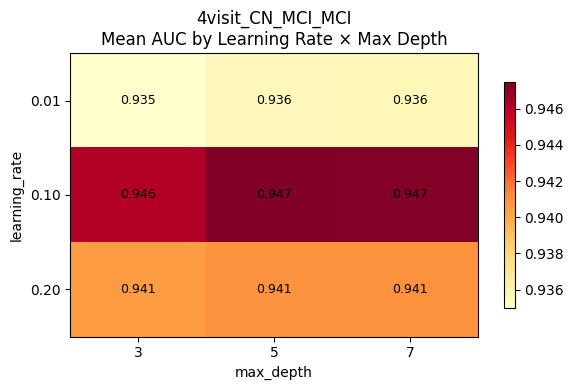

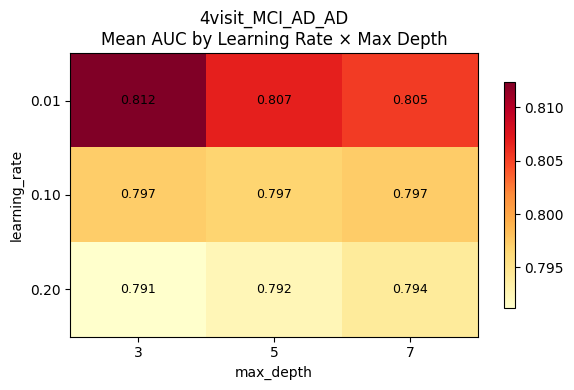

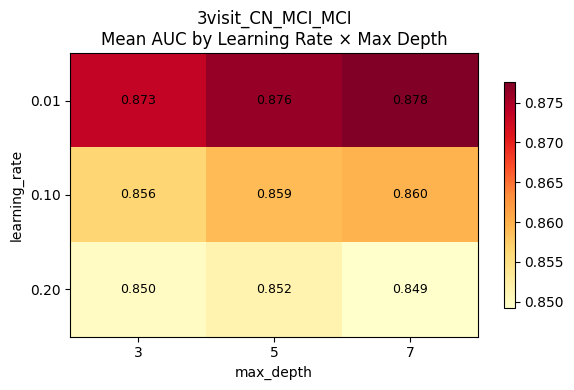

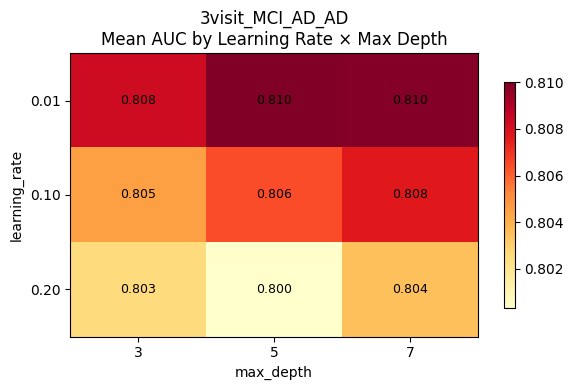

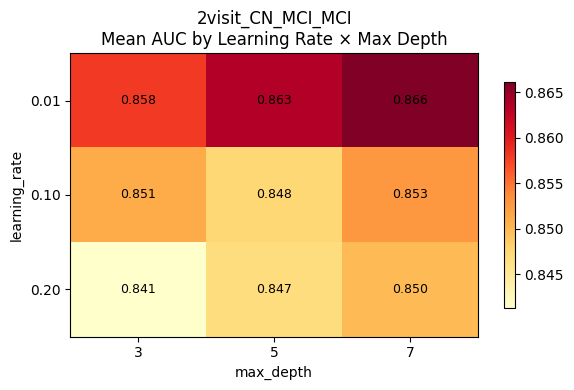

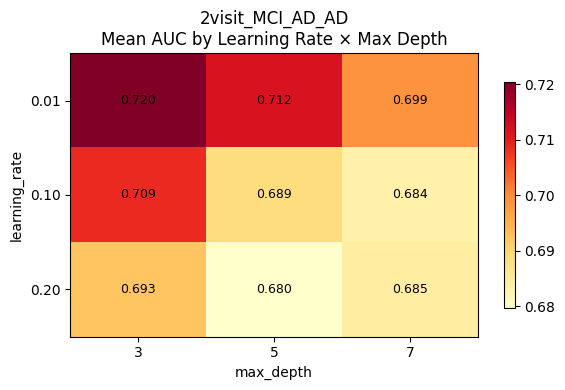


Top 10 combos for 4visit_CN_MCI_MCI:
 n_estimators  max_depth  learning_rate  subsample  colsample_bytree  avg AUC score
          100          3            0.1        0.6               1.0       0.954128
          200          5            0.1        0.6               0.6       0.953429
          200          7            0.1        0.6               0.6       0.953429
          100          5            0.1        0.8               1.0       0.952818
          200          7            0.1        0.8               1.0       0.952730
          100          7            0.1        0.8               1.0       0.952556
          200          5            0.1        0.8               1.0       0.952556
          200          3            0.1        0.6               0.6       0.952119
          300          7            0.1        0.8               1.0       0.952119
          300          5            0.1        0.8               1.0       0.951857

Best AUC: 0.9541
AUC range in top 10:

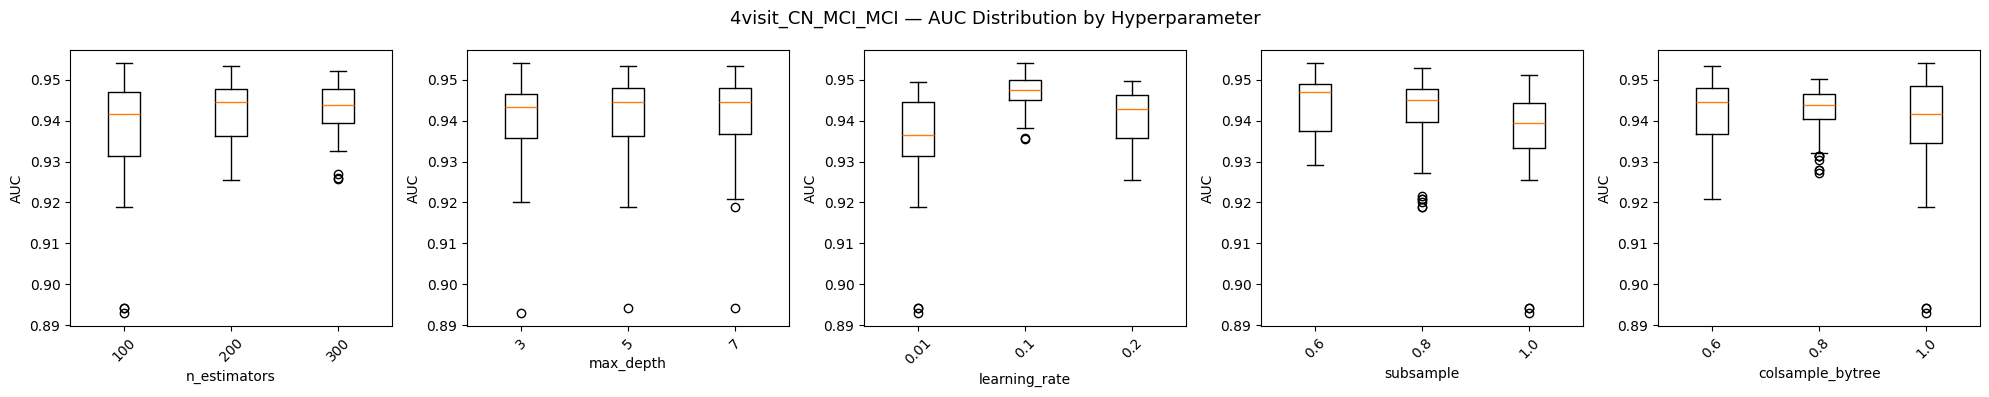

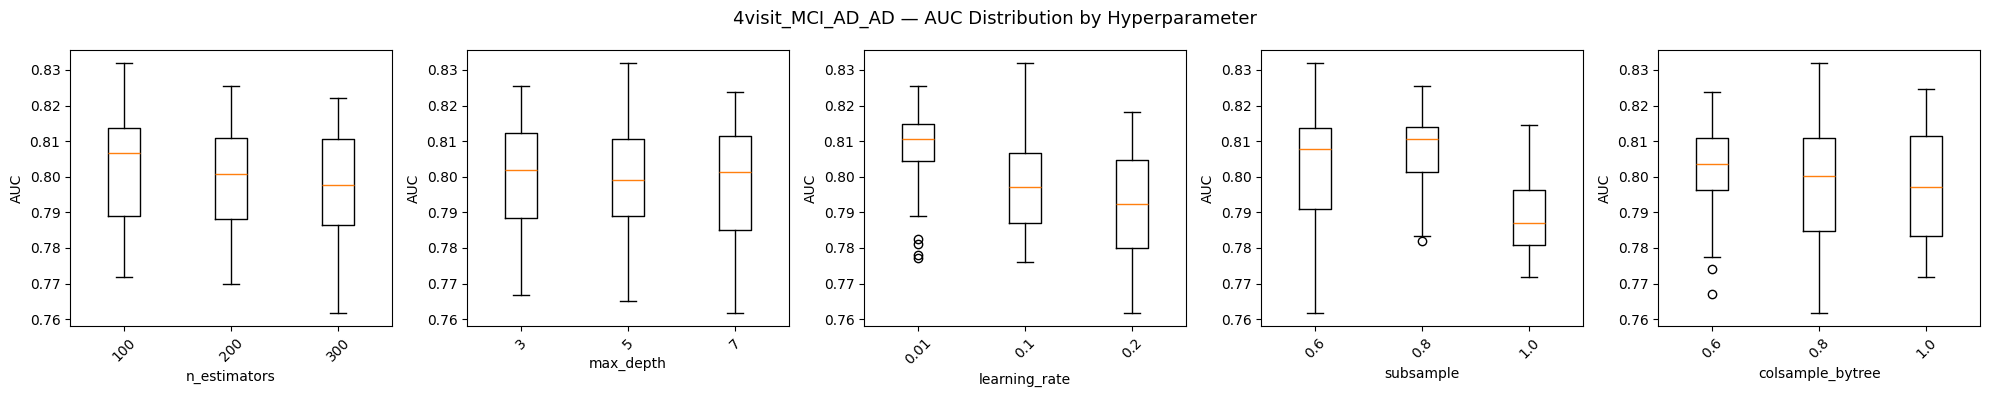

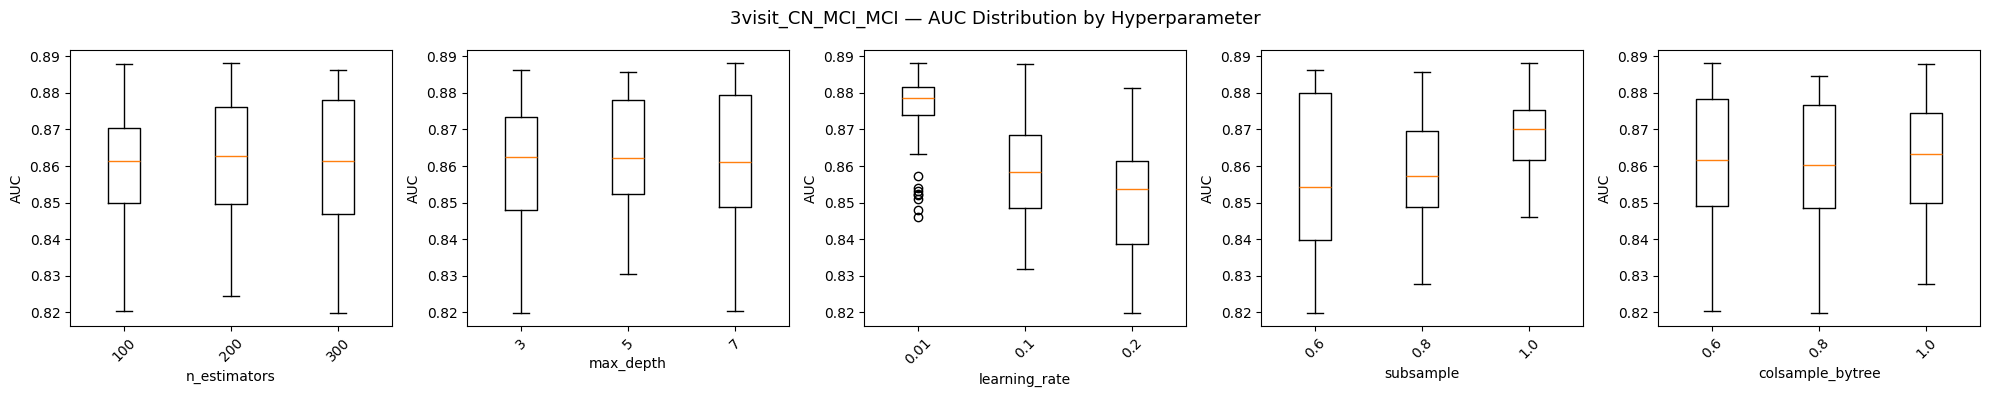

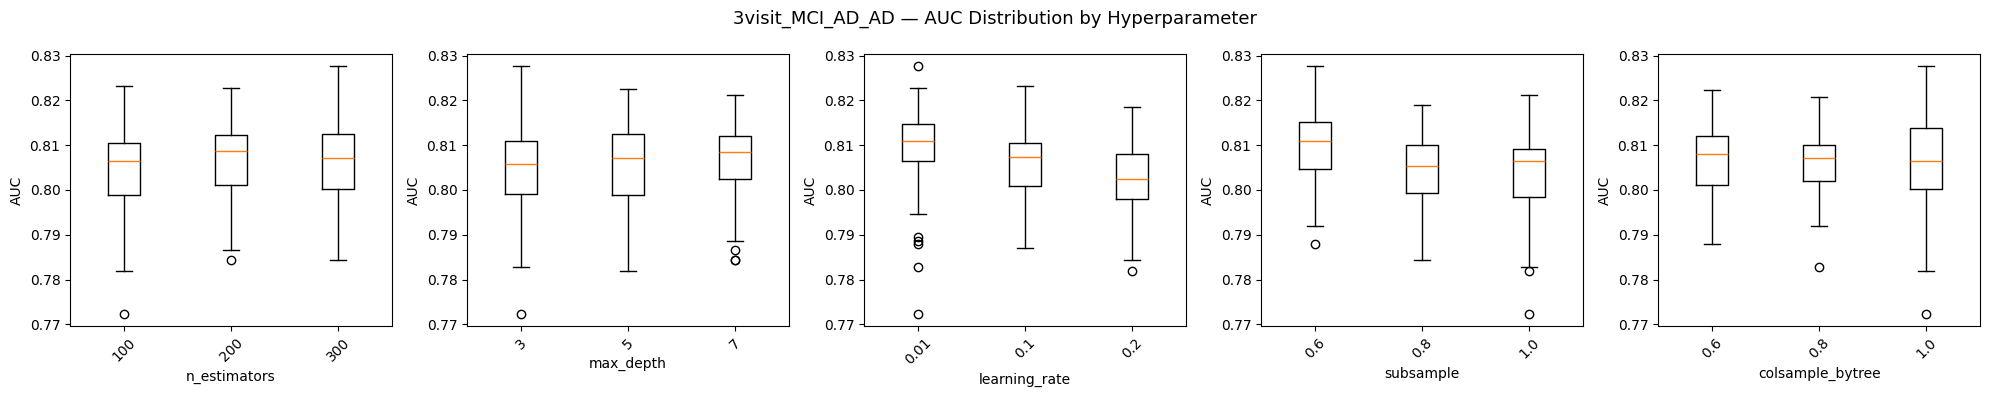

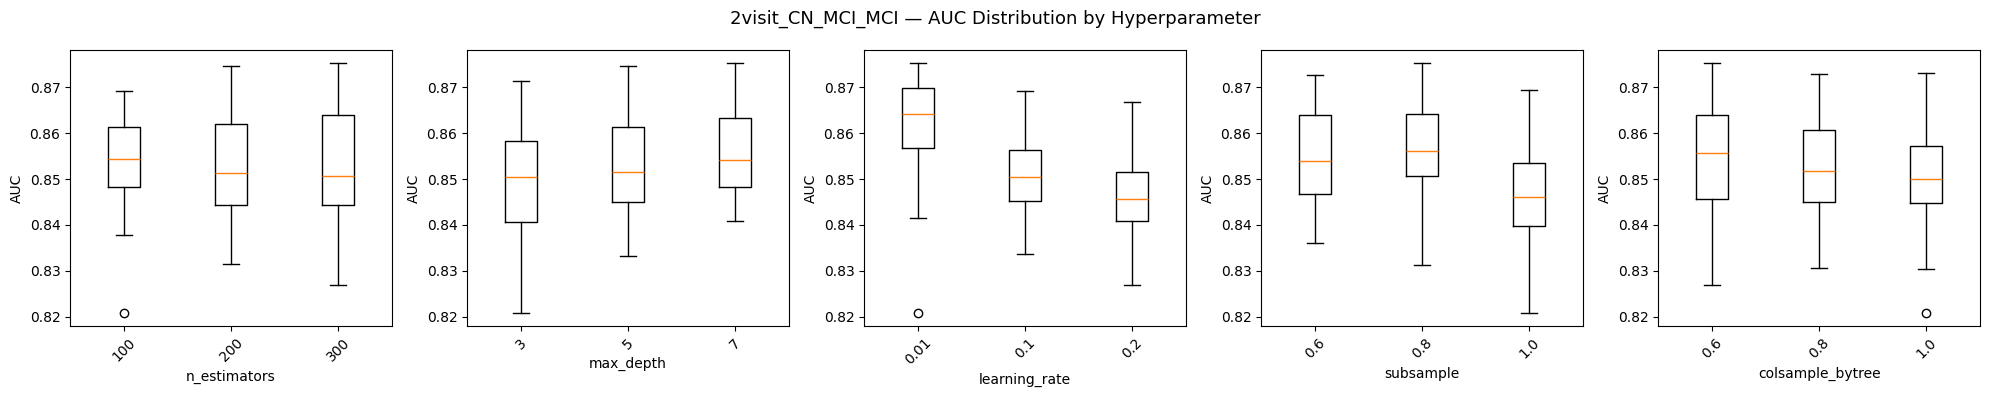

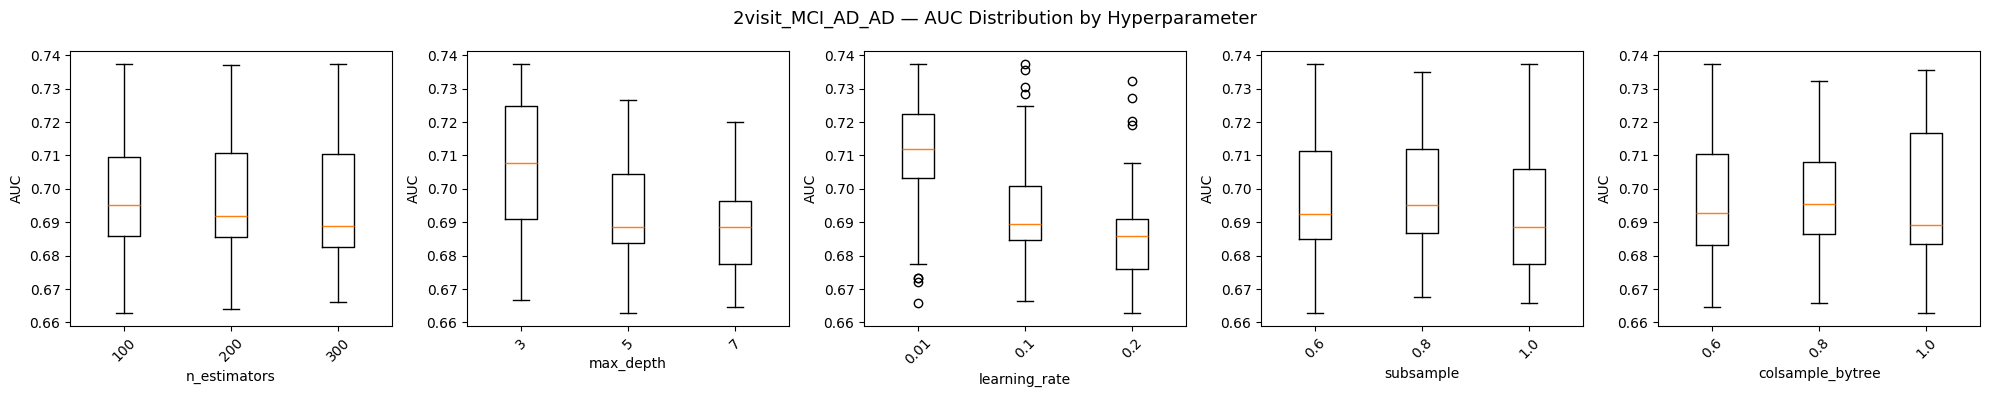

In [4]:
import matplotlib.pyplot as plt
import numpy as np

### 1. AUC Heatmaps: learning_rate vs max_depth ###
for label, scores_df in exp5_results.items():
    pivot = scores_df.groupby(['learning_rate', 'max_depth'])['avg AUC score'].mean().unstack()
    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{v:.2f}" for v in pivot.index])
    ax.set_xlabel('max_depth')
    ax.set_ylabel('learning_rate')
    ax.set_title(f'{label}\nMean AUC by Learning Rate × Max Depth')
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha='center', va='center', fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()

### 2. Top 10 Hyperparameter Combos ###
for label, scores_df in exp5_results.items():
    top10 = scores_df.nlargest(10, 'avg AUC score')
    print(f"\n{'='*60}")
    print(f"Top 10 combos for {label}:")
    print(f"{'='*60}")
    print(top10.to_string(index=False))
    print(f"\nBest AUC: {top10['avg AUC score'].iloc[0]:.4f}")
    print(f"AUC range in top 10: {top10['avg AUC score'].iloc[0] - top10['avg AUC score'].iloc[-1]:.4f}")

### 3. Box Plots: AUC Distribution by Hyperparameter ###
hp_names = ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree']

for label, scores_df in exp5_results.items():
    fig, axes = plt.subplots(1, len(hp_names), figsize=(4 * len(hp_names), 4))
    fig.suptitle(f'{label} — AUC Distribution by Hyperparameter', fontsize=13)
    for ax, hp in zip(axes, hp_names):
        groups = [group['avg AUC score'].values for _, group in scores_df.groupby(hp)]
        tick_labels = [str(v) for v in sorted(scores_df[hp].unique())]
        ax.boxplot(groups, tick_labels=tick_labels)
        ax.set_xlabel(hp)
        ax.set_ylabel('AUC')
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

# Experiment 6

### Repeating LOOCV without SMOTE, last run did not have XGBoost native imbalanced class weighting scheme. 

### Also re-creating the 5 visit cohort to remove the cropped samples can be used for lead-time analysis. 

Other changes:
1. do_impute on pipeline set to true so BMI, GDS, and categorical variables are now imputed based on per row information instead of with Iterative Imputer. MMSE imputation remains the same (within training loop). 
2. scale_pos weight. 
3. 

In [1]:
import importlib
import model as model_module
importlib.reload(model_module)
from model import train_best_model
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

files = [
    ("datasets/Dataset_final/original_5visit_CN_MCI.csv", "MCI"),
    ("datasets/Dataset_final/original_5visit_MCI_AD.csv", "AD"),
    ("datasets/Dataset_final/4visit_CN_MCI.csv", "MCI"),
    ("datasets/Dataset_final/4visit_MCI_AD.csv", "AD"),
    ("datasets/Dataset_final/3visit_CN_MCI.csv", "MCI"),
    ("datasets/Dataset_final/3visit_MCI_AD.csv", "AD"),
    ("datasets/Dataset_final/2visit_CN_MCI.csv", "MCI"),
    ("datasets/Dataset_final/2visit_MCI_AD.csv", "AD"),    

]

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

results_dir = "experiments/experiment_6/grid_results"
os.makedirs(results_dir, exist_ok=True)

exp6_results = {}  # Store results for visualization

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Running grid search for {base} ({prog}) ===")
        print(f"{'='*60}")
        model, cols = train_best_model(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="experiments/experiment_6",
            use_smote=False,
            cv_method='loocv',
            n_jobs=11,
            model_base_name=base,
            save_artifacts=True,
        )
        exp6_results[f"{base}_{prog}"] = pd.read_csv(csv_out)
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()



=== Running grid search for original_5visit_CN_MCI (MCI) ===

Mode A: LOOCV without SMOTE — full dataset (383 samples)
MMSE imputation: per-fold (fit on N-1)
Using Leave-One-Out CV (383 iterations x 243 combos, use_smote=False, n_jobs=11)


LOOCV final evaluation: 100%|██████████| 383/383 [18:17<00:00,  2.87s/fold]


Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       370
           1       0.40      0.15      0.22        13

    accuracy                           0.96       383
   macro avg       0.69      0.57      0.60       383
weighted avg       0.95      0.96      0.96       383


ROC AUC Score: 0.7661
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.963 (CI: 0.943, 0.979) range=0.037
- Precision (macro): 0.685 (CI: 0.482, 0.984) range=0.503
- Recall (macro): 0.573 (CI: 0.493, 0.686) range=0.193
- F1 (macro): 0.602 (CI: 0.489, 0.731) range=0.243
- ROC AUC: 0.766 (CI: 0.598, 0.903) range=0.305

Saved report: experiments/experiment_6/original_5visit_CN_MCI_report_MCI.txt

=== Running grid search for original_5visit_MCI_AD (AD) ===

Mode A: LOOCV without SMOTE — full dataset (120 samples)
MMSE imputation: per-fold (fit on N-1)
Usi

LOOCV final evaluation: 100%|██████████| 120/120 [02:47<00:00,  1.39s/fold]


Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.53      0.80      0.64        10
           1       0.98      0.94      0.96       110

    accuracy                           0.93       120
   macro avg       0.76      0.87      0.80       120
weighted avg       0.94      0.93      0.93       120


ROC AUC Score: 0.9518
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.925 (CI: 0.875, 0.967) range=0.092
- Precision (macro): 0.757 (CI: 0.618, 0.889) range=0.271
- Recall (macro): 0.868 (CI: 0.727, 0.978) range=0.251
- F1 (macro): 0.799 (CI: 0.650, 0.908) range=0.258
- ROC AUC: 0.952 (CI: 0.897, 0.991) range=0.094

Saved report: experiments/experiment_6/original_5visit_MCI_AD_report_AD.txt

=== Running grid search for 4visit_CN_MCI (MCI) ===

Mode A: LOOCV without SMOTE — full dataset (566 samples)
MMSE imputation: per-fold (fit on N-1)
Using Leave-

...

Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.40      0.64      0.49        36
           1       0.92      0.82      0.87       190

    accuracy                           0.79       226
   macro avg       0.66      0.73      0.68       226
weighted avg       0.84      0.79      0.81       226


ROC AUC Score: 0.8386
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.792 (CI: 0.735, 0.845) range=0.111
- Precision (macro): 0.663 (CI: 0.594, 0.733) range=0.139
- Recall (macro): 0.730 (CI: 0.643, 0.812) range=0.169
- F1 (macro): 0.682 (CI: 0.601, 0.755) range=0.153
- ROC AUC: 0.839 (CI: 0.771, 0.902) range=0.131

Saved report: experiments/experiment_6/4visit_MCI_AD_report_AD.txt

=== Running grid search for 3visit_CN_MCI (MCI) ===

Mode A: LOOCV without SMOTE — full dataset (592 samples)
MMSE imputation: not needed
Using Leave-One-Out CV (592 iter

LOOCV final evaluation: 100%|██████████| 592/592 [10:54<00:00,  1.11s/fold]


Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       556
           1       0.43      0.44      0.44        36

    accuracy                           0.93       592
   macro avg       0.70      0.70      0.70       592
weighted avg       0.93      0.93      0.93       592


ROC AUC Score: 0.8925
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.931 (CI: 0.910, 0.951) range=0.041
- Precision (macro): 0.698 (CI: 0.622, 0.779) range=0.158
- Recall (macro): 0.703 (CI: 0.625, 0.786) range=0.160
- F1 (macro): 0.701 (CI: 0.627, 0.775) range=0.148
- ROC AUC: 0.893 (CI: 0.817, 0.947) range=0.129

Saved report: experiments/experiment_6/3visit_CN_MCI_report_MCI.txt

=== Running grid search for 3visit_MCI_AD (AD) ===

Mode A: LOOCV without SMOTE — full dataset (289 samples)
MMSE imputation: not needed
Using Leave-One-Out CV (289 iter

LOOCV grid search:   9%|▉         | 22/243 [08:05<1:21:16, 22.07s/combo] 


KeyboardInterrupt: 

In [2]:
import importlib
import model as model_module
importlib.reload(model_module)
from model import train_best_model
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

files = [
    ("datasets/Dataset_final/3visit_MCI_AD.csv", "AD"),
    ("datasets/Dataset_final/2visit_CN_MCI.csv", "MCI"),
    ("datasets/Dataset_final/2visit_MCI_AD.csv", "AD"),    

]

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

results_dir = "experiments/experiment_6/grid_results"
os.makedirs(results_dir, exist_ok=True)

exp6_results = {}  # Store results for visualization

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Running grid search for {base} ({prog}) ===")
        print(f"{'='*60}")
        model, cols = train_best_model(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="experiments/experiment_6",
            use_smote=False,
            cv_method='loocv',
            n_jobs=11,
            model_base_name=base,
            save_artifacts=True,
        )
        exp6_results[f"{base}_{prog}"] = pd.read_csv(csv_out)
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()



=== Running grid search for 3visit_MCI_AD (AD) ===

Mode A: LOOCV without SMOTE — full dataset (289 samples)
MMSE imputation: not needed
Using Leave-One-Out CV (289 iterations x 243 combos, use_smote=False, n_jobs=11)


LOOCV final evaluation: 100%|██████████| 289/289 [02:39<00:00,  1.81fold/s]


Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.62      0.60      0.61        84
           1       0.84      0.85      0.85       205

    accuracy                           0.78       289
   macro avg       0.73      0.72      0.73       289
weighted avg       0.78      0.78      0.78       289


ROC AUC Score: 0.8198
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.779 (CI: 0.733, 0.827) range=0.094
- Precision (macro): 0.731 (CI: 0.674, 0.793) range=0.119
- Recall (macro): 0.724 (CI: 0.667, 0.784) range=0.117
- F1 (macro): 0.728 (CI: 0.672, 0.784) range=0.112
- ROC AUC: 0.820 (CI: 0.767, 0.870) range=0.103

Saved report: experiments/experiment_6/3visit_MCI_AD_report_AD.txt

=== Running grid search for 2visit_CN_MCI (MCI) ===

Mode A: LOOCV without SMOTE — full dataset (1078 samples)
MMSE imputation: not needed
Using Leave-One-Out CV (1078 it

LOOCV final evaluation: 100%|██████████| 1078/1078 [34:06<00:00,  1.90s/fold]


Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.96      0.93      0.95       998
           1       0.39      0.51      0.44        80

    accuracy                           0.90      1078
   macro avg       0.67      0.72      0.69      1078
weighted avg       0.92      0.90      0.91      1078


ROC AUC Score: 0.8713
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.904 (CI: 0.886, 0.920) range=0.034
- Precision (macro): 0.673 (CI: 0.627, 0.720) range=0.093
- Recall (macro): 0.724 (CI: 0.669, 0.782) range=0.112
- F1 (macro): 0.694 (CI: 0.645, 0.738) range=0.093
- ROC AUC: 0.871 (CI: 0.821, 0.913) range=0.092

Saved report: experiments/experiment_6/2visit_CN_MCI_report_MCI.txt

=== Running grid search for 2visit_MCI_AD (AD) ===

Mode A: LOOCV without SMOTE — full dataset (435 samples)
MMSE imputation: not needed
Using Leave-One-Out CV (435 iter

LOOCV final evaluation: 100%|██████████| 435/435 [12:55<00:00,  1.78s/fold]  


Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.64      0.71      0.68       217
           1       0.68      0.61      0.64       218

    accuracy                           0.66       435
   macro avg       0.66      0.66      0.66       435
weighted avg       0.66      0.66      0.66       435


ROC AUC Score: 0.7434
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.660 (CI: 0.614, 0.703) range=0.090
- Precision (macro): 0.662 (CI: 0.617, 0.705) range=0.088
- Recall (macro): 0.660 (CI: 0.616, 0.702) range=0.086
- F1 (macro): 0.659 (CI: 0.614, 0.701) range=0.088
- ROC AUC: 0.743 (CI: 0.697, 0.789) range=0.091

Saved report: experiments/experiment_6/2visit_MCI_AD_report_AD.txt


# Experiment 7

- Pooled visit-agnostic model (2–5 visits combined into one dataset)
- 5-fold Stratified K-Fold CV
- XGBoost native class weighting (`scale_pos_weight`, no SMOTE)
- Visit-agnostic features: mean, max, min, std, range, slope, first, last, last−first, acceleration, n_visits
- `progression_type='CN'` for CN-starting model (captures CN→MCI and CN→AD)


In [2]:
import importlib
import model as model_module
importlib.reload(model_module)
from model import train_best_model
import os
import pandas as pd

files = [
    ("datasets/Dataset_pooled/pooled_CN.csv", "CN"),
    ("datasets/Dataset_pooled/pooled_MCI_AD.csv", "AD"),
]

param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 9],
    'learning_rate': [0.001, 0.005, 0.01, 0.1, 0.2],
    'subsample': [0.4, 0.6, 0.8, 1.0],
    'colsample_bytree': [0.4, 0.6, 0.8, 1.0]
}

results_dir = "experiments/experiment_7/grid_results"
os.makedirs(results_dir, exist_ok=True)

exp7_results = {}

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Grid search: {base} ({prog}) — {len(df)} samples ===")
        print(f"{'='*60}")
        model, cols = train_best_model(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="experiments/experiment_7",
            use_smote=False,
            cv_method='skf',
            n_jobs=11,
            model_base_name=base,
            save_artifacts=True,
        )
        exp7_results[f"{base}_{prog}"] = pd.read_csv(csv_out)
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()



=== Grid search: pooled_CN (CN) — 2619 samples ===
Fitting MMSE imputer on training set (2095 samples) with 16 covariates...


/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MMSE imputation complete (train fit, test transformed).
Using StratifiedKFold with n_splits=5 (use_smote=False)
Grid search: 2400 hyperparameter combinations (n_jobs=11)


SKF grid search: 100%|██████████| 2400/2400 [05:28<00:00,  7.30combo/s]


SMOTE disabled: using 2095 training samples as-is (scale_pos_weight=16.46)
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       494
           1       0.40      0.70      0.51        30

    accuracy                           0.92       524
   macro avg       0.69      0.82      0.73       524
weighted avg       0.95      0.92      0.93       524


ROC AUC Score: 0.8916
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.922 (CI: 0.899, 0.945) range=0.046
- Precision (macro): 0.689 (CI: 0.624, 0.759) range=0.135
- Recall (macro): 0.818 (CI: 0.735, 0.898) range=0.163
- F1 (macro): 0.732 (CI: 0.661, 0.801) range=0.141
- ROC AUC: 0.892 (CI: 0.812, 0.951) range=0.139

Saved artifacts:
- Model:   experiments/experiment_7/pooled_CN_model_CN.pkl
- Scaler:  experiments/experiment_7/pooled_CN_scaler_CN.pkl
- Imputer: experiments/experiment_7

/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MMSE imputation complete (train fit, test transformed).
Using StratifiedKFold with n_splits=5 (use_smote=False)
Grid search: 2400 hyperparameter combinations (n_jobs=11)


SKF grid search: 100%|██████████| 2400/2400 [03:32<00:00, 11.28combo/s]


SMOTE disabled: using 856 training samples as-is (scale_pos_weight=0.48)
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.74      0.66        69
           1       0.86      0.76      0.81       145

    accuracy                           0.75       214
   macro avg       0.73      0.75      0.73       214
weighted avg       0.77      0.75      0.76       214


ROC AUC Score: 0.8166
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.752 (CI: 0.696, 0.813) range=0.117
- Precision (macro): 0.726 (CI: 0.665, 0.786) range=0.120
- Recall (macro): 0.749 (CI: 0.685, 0.812) range=0.127
- F1 (macro): 0.732 (CI: 0.667, 0.794) range=0.126
- ROC AUC: 0.817 (CI: 0.757, 0.879) range=0.122

Saved artifacts:
- Model:   experiments/experiment_7/pooled_MCI_AD_model_AD.pkl
- Scaler:  experiments/experiment_7/pooled_MCI_AD_scaler_AD.pkl
- Imputer: experiments/experi

# Experiment 8: Using SMOTE
- Using k_nearest neighbors k=3

In [3]:
import importlib
import model as model_module
importlib.reload(model_module)
from model import train_best_model
import os
import pandas as pd

files = [
    ("datasets/Dataset_pooled/pooled_CN.csv", "CN"),
    ("datasets/Dataset_pooled/pooled_MCI_AD.csv", "AD"),
]

param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 9],
    'learning_rate': [0.001, 0.005, 0.01, 0.1, 0.2],
    'subsample': [0.4, 0.6, 0.8, 1.0],
    'colsample_bytree': [0.4, 0.6, 0.8, 1.0]
}

results_dir = "experiments/experiment_8/grid_results"
os.makedirs(results_dir, exist_ok=True)

exp8_results = {}

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Grid search: {base} ({prog}) — {len(df)} samples ===")
        print(f"{'='*60}")
        model, cols = train_best_model(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="experiments/experiment_8",
            use_smote=True,
            cv_method='skf',
            n_jobs=11,
            model_base_name=base,
            save_artifacts=True,
        )
        exp8_results[f"{base}_{prog}"] = pd.read_csv(csv_out)
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()



=== Grid search: pooled_CN (CN) — 2619 samples ===
Fitting MMSE imputer on training set (2095 samples) with 16 covariates...


/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MMSE imputation complete (train fit, test transformed).
Using StratifiedKFold with n_splits=5 (use_smote=True)
Grid search: 2400 hyperparameter combinations (n_jobs=11)


SKF grid search:  19%|█▉        | 455/2400 [02:10<09:12,  3.52combo/s]/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
SKF grid search: 100%|██████████| 2400/2400 [23:16<00:00,  1.72combo/s]


SMOTE resampling: 2095 -> 3950 training samples
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       494
           1       0.39      0.47      0.42        30

    accuracy                           0.93       524
   macro avg       0.68      0.71      0.69       524
weighted avg       0.93      0.93      0.93       524


ROC AUC Score: 0.8845
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.927 (CI: 0.905, 0.950) range=0.046
- Precision (macro): 0.678 (CI: 0.597, 0.763) range=0.166
- Recall (macro): 0.711 (CI: 0.620, 0.800) range=0.180
- F1 (macro): 0.693 (CI: 0.606, 0.769) range=0.163
- ROC AUC: 0.884 (CI: 0.803, 0.945) range=0.143

Saved artifacts:
- Model:   experiments/experiment_8/pooled_CN_model_CN.pkl
- Scaler:  experiments/experiment_8/pooled_CN_scaler_CN.pkl
- Imputer: experiments/experiment_8/pooled_CN_imputer_CN.pkl
-

/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MMSE imputation complete (train fit, test transformed).
Using StratifiedKFold with n_splits=5 (use_smote=True)
Grid search: 2400 hyperparameter combinations (n_jobs=11)


SKF grid search: 100%|██████████| 2400/2400 [12:43<00:00,  3.14combo/s]


SMOTE resampling: 856 -> 1156 training samples
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.67      0.65        69
           1       0.84      0.82      0.83       145

    accuracy                           0.77       214
   macro avg       0.74      0.74      0.74       214
weighted avg       0.77      0.77      0.77       214


ROC AUC Score: 0.8185
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.771 (CI: 0.715, 0.827) range=0.112
- Precision (macro): 0.738 (CI: 0.674, 0.802) range=0.129
- Recall (macro): 0.744 (CI: 0.680, 0.808) range=0.128
- F1 (macro): 0.741 (CI: 0.677, 0.801) range=0.124
- ROC AUC: 0.818 (CI: 0.759, 0.880) range=0.121

Saved artifacts:
- Model:   experiments/experiment_8/pooled_MCI_AD_model_AD.pkl
- Scaler:  experiments/experiment_8/pooled_MCI_AD_scaler_AD.pkl
- Imputer: experiments/experiment_8/pooled_MCI_AD_imput

In [2]:
import importlib
import model as model_module
importlib.reload(model_module)
from model import evaluate_lead_time_full, add_time_dimension, create_delta_features, preprocess_data
import joblib
import pandas as pd
import numpy as np

# ── Load lead-time cohorts ──
lt_cn = add_time_dimension(pd.read_csv("datasets/Dataset_pooled/lead_time_CN.csv"))
lt_ad = add_time_dimension(pd.read_csv("datasets/Dataset_pooled/lead_time_MCI_AD.csv"))

# ── Derive feature names from training data ──
def get_feature_names(csv_path, prog_type):
    df = pd.read_csv(csv_path)
    if prog_type == 'AD':
        df['target'] = df.apply(model_module.create_target_variable_ad, axis=1)
    else:
        df['target'] = df.apply(model_module.create_target_variable_cn, axis=1)
    y = df['target'].values
    df_feat = create_delta_features(df.drop(columns=['target']))
    df_feat['target'] = y
    processed, _, _ = preprocess_data(df_feat, prog_type)
    return [c for c in processed.columns if c != 'target']

feature_names_cn = get_feature_names("datasets/Dataset_pooled/pooled_CN.csv", "CN")
feature_names_ad = get_feature_names("datasets/Dataset_pooled/pooled_MCI_AD.csv", "AD")
print(f"CN features: {len(feature_names_cn)}, AD features: {len(feature_names_ad)}")

# ── Define experiments to compare ──
experiments = {
    "Exp 7 (SKF, no SMOTE)": "experiments/experiment_7",
    "Exp 8 (SKF, SMOTE)":    "experiments/experiment_8",
}

thresholds = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

results = []

for exp_name, exp_dir in experiments.items():
    for cohort_name, lt_df, prog_type, feat_names in [
        ("CN→MCI", lt_cn, "CN", feature_names_cn),
        ("MCI→AD", lt_ad, "AD", feature_names_ad),
    ]:
        suffix = prog_type
        model   = joblib.load(f"{exp_dir}/pooled_{'CN' if prog_type=='CN' else 'MCI_AD'}_model_{suffix}.pkl")
        imputer = joblib.load(f"{exp_dir}/pooled_{'CN' if prog_type=='CN' else 'MCI_AD'}_imputer_{suffix}.pkl")
        scaler  = joblib.load(f"{exp_dir}/pooled_{'CN' if prog_type=='CN' else 'MCI_AD'}_scaler_{suffix}.pkl")

        for thr in thresholds:
            res = evaluate_lead_time_full(
                lt_df, model, imputer, scaler, feat_names,
                threshold=thr, progression_type=prog_type, min_visits=2,
            )
            lt = res['lead_times']
            sens = res['sensitivity'] if res['sensitivity'] is not None else 0.0
            spec = res['specificity'] if res['specificity'] is not None else 0.0
            mean_lt = f"{np.mean(lt):.1f}" if lt else "N/A"
            results.append({
                "Experiment": exp_name,
                "Cohort": cohort_name,
                "Threshold": thr,
                "TP": res['true_positives'],
                "FN": res['false_negatives'],
                "TN": res['true_negatives'],
                "FP": res['false_positives'],
                "Sensitivity": round(sens, 3),
                "Specificity": round(spec, 3),
                "Total Prog": res['total_progressors'],
                "Total Non-Prog": res['total_non_progressors'],
                "Mean Lead (mo)": round(np.mean(lt), 1) if lt else None,
                "Median Lead (mo)": round(np.median(lt), 1) if lt else None,
            })
            print(f"{exp_name} | {cohort_name} | thr={thr:.2f} | "
                  f"Sens={sens:.3f}, Spec={spec:.3f}, "
                  f"TP={res['true_positives']}, FP={res['false_positives']}, "
                  f"mean_lead={mean_lt}mo")

results_df = pd.DataFrame(results)
print("\n" + "="*100)
print(results_df.to_string(index=False))


CN features: 204, AD features: 204
Exp 7 (SKF, no SMOTE) | CN→MCI | thr=0.50 | Sens=0.163, Spec=0.939, TP=7, FP=66, mean_lead=44.6mo
Exp 7 (SKF, no SMOTE) | CN→MCI | thr=0.60 | Sens=0.047, Spec=0.971, TP=2, FP=32, mean_lead=42.0mo
Exp 7 (SKF, no SMOTE) | CN→MCI | thr=0.70 | Sens=0.023, Spec=0.996, TP=1, FP=4, mean_lead=72.0mo
Exp 7 (SKF, no SMOTE) | CN→MCI | thr=0.80 | Sens=0.000, Spec=1.000, TP=0, FP=0, mean_lead=N/Amo
Exp 7 (SKF, no SMOTE) | CN→MCI | thr=0.90 | Sens=0.000, Spec=1.000, TP=0, FP=0, mean_lead=N/Amo
Exp 7 (SKF, no SMOTE) | CN→MCI | thr=0.95 | Sens=0.000, Spec=1.000, TP=0, FP=0, mean_lead=N/Amo
Exp 7 (SKF, no SMOTE) | MCI→AD | thr=0.50 | Sens=0.195, Spec=0.533, TP=52, FP=7, mean_lead=17.5mo
Exp 7 (SKF, no SMOTE) | MCI→AD | thr=0.60 | Sens=0.124, Spec=0.600, TP=33, FP=6, mean_lead=16.0mo
Exp 7 (SKF, no SMOTE) | MCI→AD | thr=0.70 | Sens=0.075, Spec=0.733, TP=20, FP=4, mean_lead=16.8mo
Exp 7 (SKF, no SMOTE) | MCI→AD | thr=0.80 | Sens=0.030, Spec=0.933, TP=8, FP=1, mean_lead=

# Experiment 9
- Using k=5 for SMOTE-NC. 

In [4]:
import importlib
import model as model_module
importlib.reload(model_module)
from model import train_best_model
import os
import pandas as pd

files = [
    ("datasets/Dataset_pooled/pooled_CN.csv", "CN"),
    ("datasets/Dataset_pooled/pooled_MCI_AD.csv", "AD"),
]

param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 9],
    'learning_rate': [0.001, 0.005, 0.01, 0.1, 0.2],
    'subsample': [0.4, 0.6, 0.8, 1.0],
    'colsample_bytree': [0.4, 0.6, 0.8, 1.0]
}

results_dir = "experiments/experiment_9/grid_results"
os.makedirs(results_dir, exist_ok=True)

exp9_results = {}

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Grid search: {base} ({prog}) — {len(df)} samples ===")
        print(f"{'='*60}")
        model, cols = train_best_model(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="experiments/experiment_9",
            use_smote=True,
            cv_method='skf',
            n_jobs=11,
            k_neighbors=5,
            model_base_name=base,
            save_artifacts=True,
        )
        exp9_results[f"{base}_{prog}"] = pd.read_csv(csv_out)
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()



=== Grid search: pooled_CN (CN) — 2619 samples ===
Fitting MMSE imputer on training set (2095 samples) with 16 covariates...


/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MMSE imputation complete (train fit, test transformed).
Using StratifiedKFold with n_splits=5 (use_smote=True)
Grid search: 2400 hyperparameter combinations (n_jobs=11)


SKF grid search: 100%|██████████| 2400/2400 [23:42<00:00,  1.69combo/s]


SMOTE resampling: 2095 -> 3950 training samples. k_neighbors=5
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       494
           1       0.33      0.37      0.35        30

    accuracy                           0.92       524
   macro avg       0.65      0.66      0.65       524
weighted avg       0.93      0.92      0.92       524


ROC AUC Score: 0.8964
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.922 (CI: 0.899, 0.945) range=0.046
- Precision (macro): 0.647 (CI: 0.568, 0.731) range=0.163
- Recall (macro): 0.661 (CI: 0.573, 0.751) range=0.178
- F1 (macro): 0.654 (CI: 0.571, 0.729) range=0.158
- ROC AUC: 0.896 (CI: 0.822, 0.949) range=0.127

Saved artifacts:
- Model:   experiments/experiment_9/pooled_CN_model_CN.pkl
- Scaler:  experiments/experiment_9/pooled_CN_scaler_CN.pkl
- Imputer: experiments/experiment_9/pooled_CN_i

/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MMSE imputation complete (train fit, test transformed).
Using StratifiedKFold with n_splits=5 (use_smote=True)
Grid search: 2400 hyperparameter combinations (n_jobs=11)


SKF grid search: 100%|██████████| 2400/2400 [12:53<00:00,  3.10combo/s]


SMOTE resampling: 856 -> 1156 training samples. k_neighbors=5
Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.67      0.65        69
           1       0.84      0.81      0.83       145

    accuracy                           0.77       214
   macro avg       0.73      0.74      0.74       214
weighted avg       0.77      0.77      0.77       214


ROC AUC Score: 0.8159
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.766 (CI: 0.710, 0.827) range=0.117
- Precision (macro): 0.734 (CI: 0.669, 0.798) range=0.129
- Recall (macro): 0.740 (CI: 0.678, 0.807) range=0.129
- F1 (macro): 0.737 (CI: 0.673, 0.800) range=0.127
- ROC AUC: 0.816 (CI: 0.756, 0.876) range=0.120

Saved artifacts:
- Model:   experiments/experiment_9/pooled_MCI_AD_model_AD.pkl
- Scaler:  experiments/experiment_9/pooled_MCI_AD_scaler_AD.pkl
- Imputer: experiments/experiment_9/pool

# Experiment 10
- k_neighbors = 7

In [ ]:
import importlib
import model as model_module
importlib.reload(model_module)
from model import train_best_model
import os
import pandas as pd

files = [
    ("datasets/Dataset_pooled/pooled_CN.csv", "CN"),
    ("datasets/Dataset_pooled/pooled_MCI_AD.csv", "AD"),
]

param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 9],
    'learning_rate': [0.001, 0.005, 0.01, 0.1, 0.2],
    'subsample': [0.4, 0.6, 0.8, 1.0],
    'colsample_bytree': [0.4, 0.6, 0.8, 1.0]
}

results_dir = "experiments/experiment_10/grid_results"
os.makedirs(results_dir, exist_ok=True)

exp10_results = {}

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Grid search: {base} ({prog}) — {len(df)} samples ===")
        print(f"{'='*60}")
        model, cols = train_best_model(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="experiments/experiment_10",
            use_smote=True,
            cv_method='skf',
            n_jobs=11,
            k_neighbors=7,
            model_base_name=base,
            save_artifacts=True,
        )
        exp10_results[f"{base}_{prog}"] = pd.read_csv(csv_out)
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()


# Experiment 11
- k_neighbors = 10

In [ ]:
import importlib
import model as model_module
importlib.reload(model_module)
from model import train_best_model
import os
import pandas as pd

files = [
    ("datasets/Dataset_pooled/pooled_CN.csv", "CN"),
    ("datasets/Dataset_pooled/pooled_MCI_AD.csv", "AD"),
]

param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 9],
    'learning_rate': [0.001, 0.005, 0.01, 0.1, 0.2],
    'subsample': [0.4, 0.6, 0.8, 1.0],
    'colsample_bytree': [0.4, 0.6, 0.8, 1.0]
}

results_dir = "experiments/experiment_11/grid_results"
os.makedirs(results_dir, exist_ok=True)

exp11_results = {}

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Grid search: {base} ({prog}) — {len(df)} samples ===")
        print(f"{'='*60}")
        model, cols = train_best_model(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="experiments/experiment_11",
            use_smote=True,
            cv_method='skf',
            n_jobs=11,
            k_neighbors=10,
            model_base_name=base,
            save_artifacts=True,
        )
        exp11_results[f"{base}_{prog}"] = pd.read_csv(csv_out)
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()
